In [1]:
import os
folder_path = r"C:\Users\MainUser\Downloads\cs230_data"
files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
print(len(files))

1260


In [3]:
#%pip install databento
import databento as db

sample_file = f"{folder_path}\\{files[0]}"
data = db.DBNStore.from_file(sample_file)
df = data.to_df()
df.head()

,ts_event,rtype,publisher_id,instrument_id,side,price,size,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00,symbol
ts_recv,,,,,,,,,,,,,,,,
2020-10-05 04:23:27+00:00,NaT,195,43,15144,N,NaN,0,128,1025,NaN,NaN,0,0,0,0,SPY
2020-10-05 08:00:01+00:00,2020-10-05 08:00:00.667475968+00:00,195,43,15144,N,335.15,500,130,6792,335.13,335.25,500,500,1,1,SPY
2020-10-05 08:00:02+00:00,2020-10-05 08:00:01.770952192+00:00,195,43,15144,A,335.11,500,130,7385,335.11,335.23,500,500,1,1,SPY
2020-10-05 08:00:03+00:00,2020-10-05 08:00:02.716659200+00:00,195,43,15144,A,335.13,500,130,7677,335.15,335.25,500,500,1,1,SPY
2020-10-05 08:00:04+00:00,2020-10-05 08:00:03.371110400+00:00,195,43,15144,A,335.08,300,130,7955,335.11,335.22,500,500,1,1,SPY


In [4]:

df["weighted_mid"] = (
    df["bid_px_00"] * df["ask_sz_00"] + df["ask_px_00"] * df["bid_sz_00"]
) / (df["bid_sz_00"] + df["ask_sz_00"])

# --- Ensure 1-second frequency ---
df = df.sort_index()
df = df.resample("1s").ffill()

# --- Compute returns ---
df["ret_1s"] = df["weighted_mid"].pct_change()
df["ret_sq"] = df["ret_1s"] ** 2

# --- Realized variance per 60-second window ---
rv_60s = df["ret_sq"].resample("60s").sum()
df["rv_60s"] = rv_60s.reindex(df.index, method="ffill")

ret_1min = df["weighted_mid"].resample("60s").last().pct_change()
df["ret_60s"] = ret_1min.reindex(df.index, method="ffill")

df.tail()

,ts_event,rtype,publisher_id,instrument_id,side,price,size,flags,sequence,bid_px_00,...,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00,symbol,weighted_mid,ret_1s,ret_sq,rv_60s,ret_60s
ts_recv,,,,,,,,,,,,,,,,,,,,,
2020-10-05 23:59:55+00:00,2020-10-05 23:59:48.836021504+00:00,195,43,15144,A,338.90,20,130,22780766,338.9,...,230,5,1,1,SPY,338.909787,0.000000,0.000000e+00,2.377690e-08,0.000074
2020-10-05 23:59:56+00:00,2020-10-05 23:59:48.836021504+00:00,195,43,15144,A,338.90,20,130,22780766,338.9,...,230,5,1,1,SPY,338.909787,0.000000,0.000000e+00,2.377690e-08,0.000074
2020-10-05 23:59:57+00:00,2020-10-05 23:59:48.836021504+00:00,195,43,15144,A,338.90,20,130,22780766,338.9,...,230,5,1,1,SPY,338.909787,0.000000,0.000000e+00,2.377690e-08,0.000074
2020-10-05 23:59:58+00:00,2020-10-05 23:59:48.836021504+00:00,195,43,15144,A,338.90,20,130,22780766,338.9,...,230,5,1,1,SPY,338.909787,0.000000,0.000000e+00,2.377690e-08,0.000074
2020-10-05 23:59:59+00:00,2020-10-05 23:59:58.822274816+00:00,195,43,15144,B,338.92,95,130,22780871,338.9,...,230,139,1,1,SPY,338.912466,0.000008,6.248010e-11,2.377690e-08,0.000074


In [5]:
import pandas as pd

first_date = df.index[0].normalize()
session_start = first_date + pd.Timedelta(hours=8, minutes=1)
df = df[df.index >= session_start]

df_1min = df[df.index.second == 0].copy()
print(len(df_1min))
df_1min.head()


959


,ts_event,rtype,publisher_id,instrument_id,side,price,size,flags,sequence,bid_px_00,...,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00,symbol,weighted_mid,ret_1s,ret_sq,rv_60s,ret_60s
ts_recv,,,,,,,,,,,,,,,,,,,,,
2020-10-05 08:01:00+00:00,2020-10-05 08:00:45.732831232+00:00,195,43,15144,A,335.25,899,130,11283,335.23,...,500,1,1,1,SPY,335.249960,0.000000,0.000000e+00,1.859390e-07,0.000612
2020-10-05 08:02:00+00:00,2020-10-05 08:01:57.329287680+00:00,195,43,15144,B,335.43,299,130,13757,335.43,...,500,500,1,1,SPY,335.455000,0.000000,0.000000e+00,8.195841e-08,-0.000012
2020-10-05 08:03:00+00:00,2020-10-05 08:02:55.611460608+00:00,195,43,15144,A,335.46,50,130,15890,335.43,...,400,552,1,2,SPY,335.451008,0.000000,0.000000e+00,4.866767e-08,-0.000018
2020-10-05 08:04:00+00:00,2020-10-05 08:03:39.636137728+00:00,195,43,15144,A,335.48,48,130,17613,335.43,...,500,1000,1,2,SPY,335.446667,0.000005,2.468623e-11,1.045979e-07,0.000043
2020-10-05 08:05:00+00:00,2020-10-05 08:04:42.617579520+00:00,195,43,15144,N,335.46,90,130,19603,335.42,...,100,1000,1,2,SPY,335.425455,-0.000101,1.026644e-08,9.166095e-08,-0.000038


<Axes: xlabel='ts_recv'>

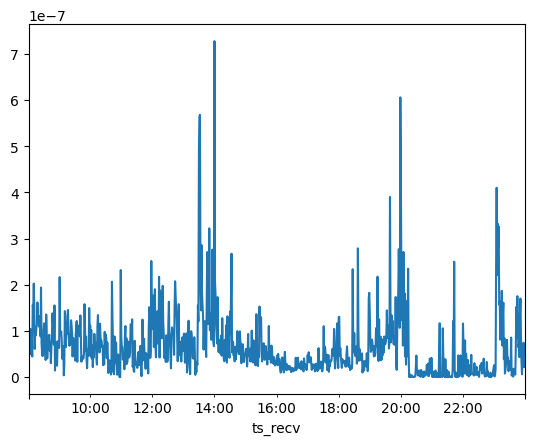

In [6]:
df_1min["rv_60s"].plot()

<Axes: xlabel='ts_recv'>

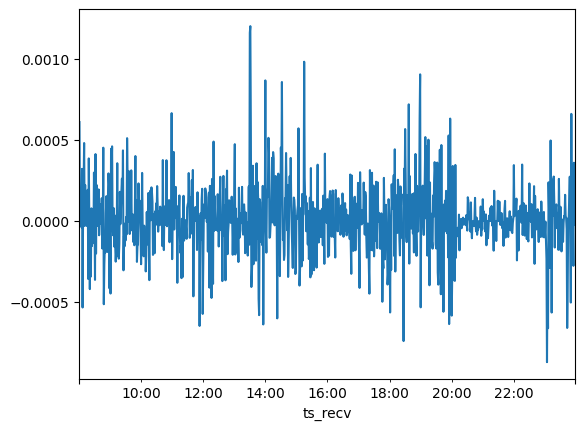

In [7]:
df_1min["ret_60s"].plot()